# Model 1: Logistic Regression with SHAP Explainability

HEART DISEASE PREDICTION - LOGISTIC REGRESSION MODEL
Dataset loaded successfully!
Shape: (918, 12)

First 5 rows:
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data 

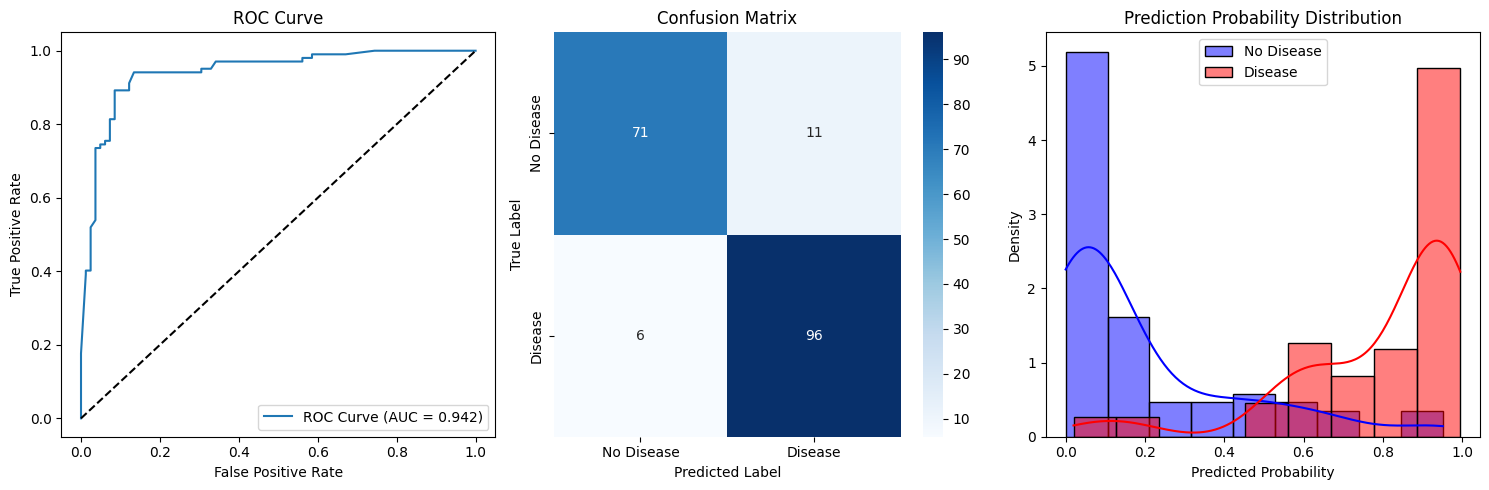


SHAP EXPLANATIONS


PermutationExplainer explainer: 185it [00:12,  5.14it/s]



SHAP Summary Plot:


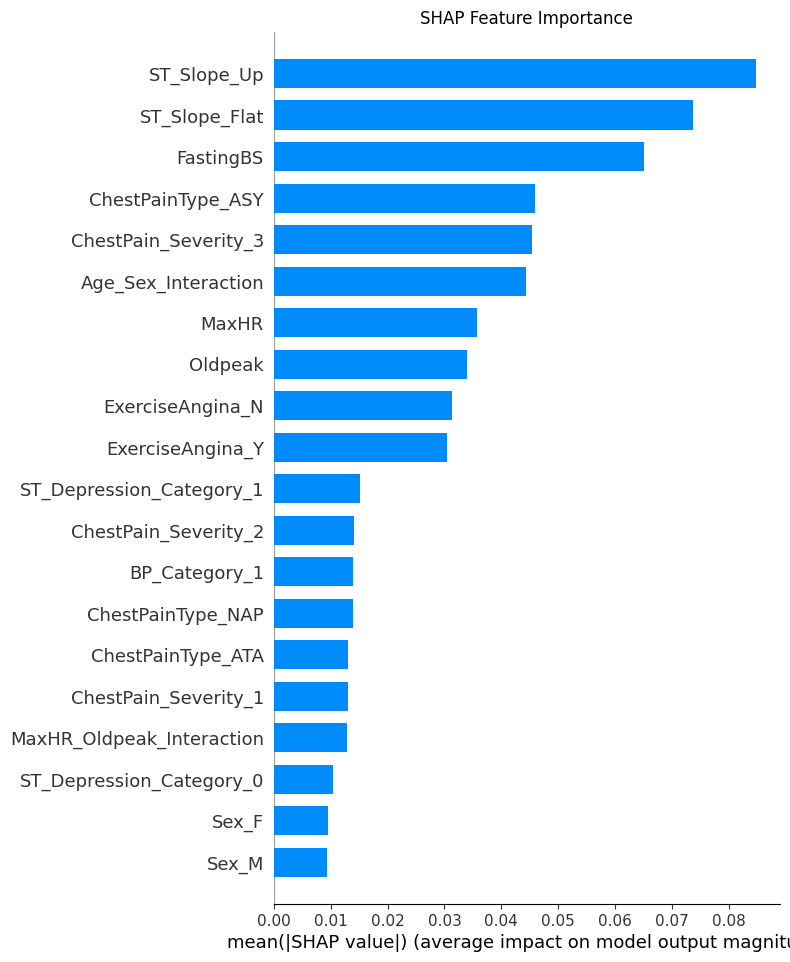

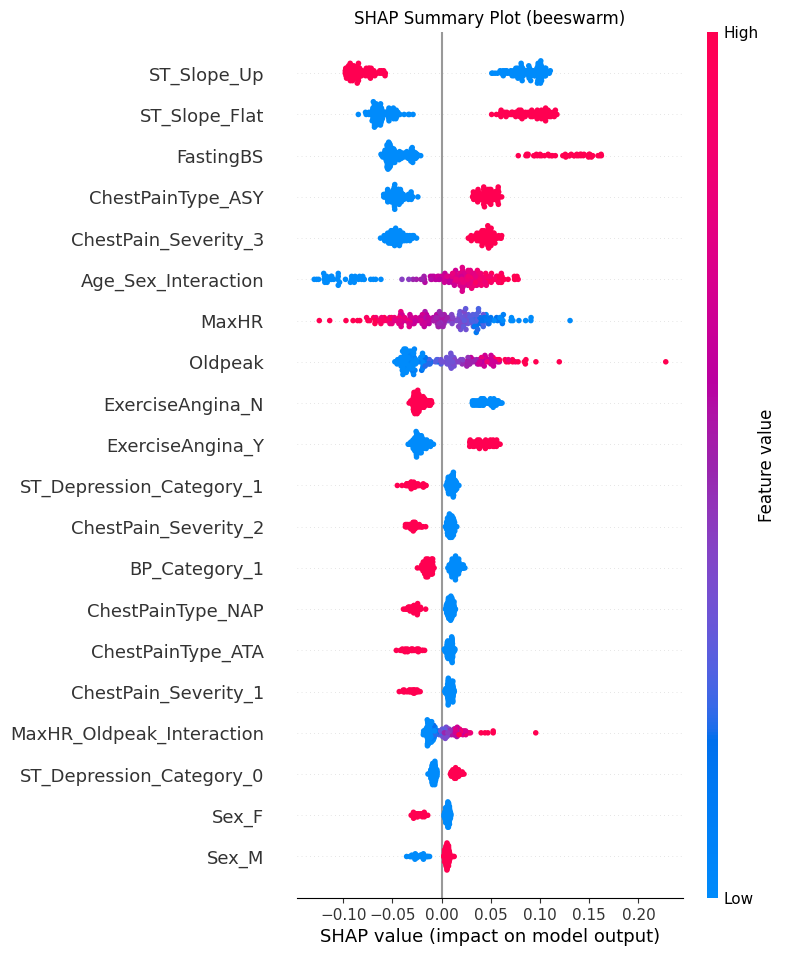


SHAP Explanation for a Sample Case:
Error during SHAP explanation: waterfall() got an unexpected keyword argument 'feature_names'
Please ensure shap is installed (`pip install shap`) and the model/data are correctly formatted.

SINGLE CASE PREDICTION
Using internal sample case for prediction.

Input Data:
     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
356   46   M           ASY        115            0          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  
356    113              Y      1.5     Flat  

Predicted Probability of Heart Disease (Class 1): 0.9512
Predicted Class: 1

SHAP Explanation for this Prediction:
Error generating SHAP explanation for single case: waterfall() got an unexpected keyword argument 'feature_names'

SINGLE CASE PREDICTION
Using provided case data for prediction.

Input Data:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   55   F           NAP        125          230          

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, log_loss,
                             classification_report)
from sklearn.calibration import CalibratedClassifierCV
import joblib
import shap
import warnings

warnings.filterwarnings('ignore')

class HeartDiseaseLogisticModel:
    def __init__(self):
        self.data = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.model = None
        self.pipeline = None
        self.preprocessor = None
        self.feature_names = None
        self.sample_case = None # Store a sample case for explanation
        self.feature_names_before_preprocessing = None # Store feature names before preprocessing

        # Store medians for single case imputation if Cholesterol=0 is treated as missing
        self.cholesterol_median = None
        self.cholesterol_sex_age_medians = None # For more nuanced imputation

    def load_and_explore_data(self, file_path):
        """Load data and perform basic exploration."""
        print("=" * 60)
        print("HEART DISEASE PREDICTION - LOGISTIC REGRESSION MODEL")
        print("=" * 60)
        self.data = pd.read_csv(file_path)
        print(f"Dataset loaded successfully!\nShape: {self.data.shape}")
        print("\nFirst 5 rows:\n", self.data.head())
        print("\nDataset Info:")
        self.data.info()
        print("\nMissing Values:\n", self.data.isnull().sum().sum())
        if self.data.isnull().sum().sum() == 0:
            print("No missing values found!")
        print("\nStatistical Summary:\n", self.data.describe())
        print("\nTarget Variable Distribution:\n", self.data['HeartDisease'].value_counts())
        print(f"Heart Disease Rate: {self.data['HeartDisease'].mean():.2%}")
        return self.data

    def preprocess_data(self):
        """Perform comprehensive data preprocessing including feature engineering."""
        print("\n" + "=" * 40)
        print("DATA PREPROCESSING")
        print("=" * 40)
        df = self.data.copy()
        target = 'HeartDisease'

        # Feature Engineering
        print("Feature Engineering...")

        # Impute 0 cholesterol values (assuming 0 is missing)
        if (df['Cholesterol'] == 0).any():
            # Calculate medians BEFORE replacement for training set consistency
            self.cholesterol_sex_age_medians = df.groupby(['Sex', 'Age'])['Cholesterol'].median().to_dict()
            self.cholesterol_median = df['Cholesterol'].median()

            df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

            # Use a helper function for imputation to avoid direct groupby transform in single case
            # This is a temporary measure for demonstration; ideally, a custom imputer in pipeline
            # df['Cholesterol'].fillna(df.groupby(['Sex', 'Age'])['Cholesterol'].transform('median'), inplace=True)
            # df['Cholesterol'].fillna(df['Cholesterol'].median(), inplace=True)

            # A more robust imputation for training, ensuring no NaNs for single case prediction
            # For simplicity, let's use the overall median if grouped median isn't available
            df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

            print("  - Imputed 0 cholesterol values with median (overall or group based for training).")


        # Create interaction terms
        # Ensure 'Sex' is mapped to numeric if it's 'M'/'F' for multiplication
        df['Age_Sex_Interaction'] = df['Age'] * df['Sex'].map({'M': 1, 'F': 0})
        df['MaxHR_Oldpeak_Interaction'] = df['MaxHR'] * df['Oldpeak']

        # Polynomial features (example for Age)
        df['Age_Squared'] = df['Age']**2

        # Ratio features
        df['Cholesterol_MaxHR_Ratio'] = df['Cholesterol'] / (df['MaxHR'] + 1e-6) # Add small epsilon to avoid division by zero

        # Domain-specific features
        # Framingham Risk Score components (simplified)
        df['Framingham_Risk_Factors'] = (
            (df['Age'] >= 45).astype(int) +
            (df['Sex'] == 'M').astype(int) + # Keep Sex as 'M' for this check
            (df['Cholesterol'] >= 240).astype(int) +
            (df['RestingBP'] >= 140).astype(int) +
            df['FastingBS']
        )

        # Pulse Pressure (assuming RestingBP is systolic, need diastolic for true pulse pressure)
        df['PulsePressure'] = df['RestingBP']

        # Resting ECG abnormalities count
        df['ECG_Abnormalities'] = df['RestingECG'].apply(lambda x: 1 if x in ['ST', 'LVH'] else 0)

        # Chest Pain Severity (ordinal mapping)
        chest_pain_mapping = {'TA': 0, 'ATA': 1, 'NAP': 2, 'ASY': 3}
        # Apply map, then fillna for any unmapped values, then convert to int
        df['ChestPain_Severity'] = df['ChestPainType'].map(chest_pain_mapping).fillna(-1).astype(int)


        # ST Depression Category
        # Assign to a temporary series, fillna, then convert to int
        temp_st_depression = pd.cut(df['Oldpeak'], bins=[-np.inf, 0, 1, 2, np.inf], labels=[0, 1, 2, 3])
        df['ST_Depression_Category'] = temp_st_depression.cat.add_categories(-1).fillna(-1).astype(int)


        # Blood Pressure categories
        temp_bp_category = pd.cut(df['RestingBP'], bins=[0, 120, 140, 1000], labels=[0, 1, 2], right=False)
        df['BP_Category'] = temp_bp_category.cat.add_categories(-1).fillna(-1).astype(int)


        # Heart Rate categories
        temp_maxhr_category = pd.cut(df['MaxHR'], bins=[0, 100, 150, np.inf], labels=[0, 1, 2])
        df['MaxHR_Category'] = temp_maxhr_category.cat.add_categories(-1).fillna(-1).astype(int)


        print("  - Created various interaction, polynomial, ratio, and domain-specific features.")
        print(f"  - Total features after engineering: {df.shape[1] - 1}") # Subtract target column

        # Define features and target
        X = df.drop(target, axis=1)
        y = df[target]
        self.feature_names_before_preprocessing = X.columns.tolist() # Store original feature names for single case prediction

        # Define categorical and numerical features for preprocessing
        # Update categorical features with newly created ones that might be categorical
        categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
        engineered_categorical_features = ['ECG_Abnormalities', 'ChestPain_Severity', 'ST_Depression_Category', 'BP_Category', 'MaxHR_Category']

        # Add engineered categorical features if they are not already in the original list
        for col in engineered_categorical_features:
            if col not in categorical_features and col in X.columns: # Check if column actually exists in X
                categorical_features.append(col)

        # Numerical features are all columns not in the final list of categorical features
        numerical_features = [col for col in X.columns if col not in categorical_features]

        # Double check for any remaining non-numeric types in numerical features (should ideally be handled)
        for col in numerical_features:
            if X[col].dtype == 'object':
                print(f"Warning: '{col}' is still an object type but specified as numerical. Attempting conversion.")
                X[col] = pd.to_numeric(X[col], errors='coerce') # Coerce errors to NaN
                X[col].fillna(X[col].median(), inplace=True) # Fill NaNs introduced by coercion

        # Create preprocessing pipelines for numerical and categorical features
        numerical_transformer = StandardScaler()
        categorical_transformer = OneHotEncoder(handle_unknown='ignore') # Handle unseen categories during prediction

        # Create a column transformer to apply different transformations to different columns
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_features),
                ('cat', categorical_transformer, categorical_features)
            ],
            remainder='passthrough' # Keep other columns (if any)
        )

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        print("\nData splitting complete.")

        # Fit and transform data using the preprocessor
        self.X_train = self.preprocessor.fit_transform(self.X_train)
        self.X_test = self.preprocessor.transform(self.X_test)
        print("Data preprocessing (scaling and encoding) complete.")

        # Get the feature names after preprocessing
        num_feature_names = numerical_features
        cat_feature_names = self.preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

        # Handle cases where 'remainder' might add columns (e.g., if passthrough columns exist and are not num/cat)
        # In this specific case, 'remainder' should not add new columns as all are handled.
        # But for robustness, if you had 'passthrough' columns that weren't numerical_features or categorical_features
        # you'd need to get their names too. For this problem, it's fine.

        self.feature_names = np.concatenate([num_feature_names, cat_feature_names])

        # Store a sample case for SHAP explanation (using the first instance of the test set)
        if self.X_test.shape[0] > 0:
            self.sample_case = self.X_test[0, :].reshape(1, -1)
        else:
            self.sample_case = None
            print("Warning: Test set is empty, cannot create sample case for SHAP.")

        return self.X_train, self.y_train

    def train_model(self, X_train, y_train):
        """Train the Logistic Regression model with cross-validation."""
        print("\n" + "=" * 40)
        print("MODEL TRAINING")
        print("=" * 40)
        self.model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000, C=0.1)

        self.model.fit(X_train, y_train)
        print("Logistic Regression model trained successfully.")

        cv_scores = cross_val_score(self.model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc')
        print(f"\nCross-validation ROC-AUC scores: {cv_scores}")
        print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

        self.model = CalibratedClassifierCV(self.model, method='isotonic', cv=5)
        self.model.fit(X_train, y_train)
        print("Model calibrated successfully.")

        return self.model

    def evaluate_model(self):
        """Evaluate the trained model on the test set."""
        print("\n" + "=" * 40)
        print("MODEL EVALUATION")
        print("=" * 40)
        if self.model is None or self.X_test is None or self.y_test is None:
            print("Model not trained or test data not available.")
            return None

        y_pred = self.model.predict(self.X_test)
        y_proba = self.model.predict_proba(self.X_test)[:, 1]

        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred)
        recall = recall_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)
        roc_auc = roc_auc_score(self.y_test, y_proba)
        logloss = log_loss(self.y_test, y_proba)
        cm = confusion_matrix(self.y_test, y_pred)
        report = classification_report(self.y_test, y_pred)

        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'log_loss': logloss,
            'confusion_matrix': cm,
            'classification_report': report
        }

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"Log Loss: {logloss:.4f}")
        print("\nConfusion Matrix:\n", cm)
        print("\nClassification Report:\n", report)

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 3, 1)
        fpr, tpr, _ = roc_curve(self.y_test, y_proba)
        plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title('ROC Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()

        plt.subplot(1, 3, 2)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')

        plt.subplot(1, 3, 3)
        sns.histplot(y_proba[self.y_test == 0], color='blue', label='No Disease', kde=True, stat='density', common_norm=False)
        sns.histplot(y_proba[self.y_test == 1], color='red', label='Disease', kde=True, stat='density', common_norm=False)
        plt.title('Prediction Probability Distribution')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Density')
        plt.legend()

        plt.tight_layout()
        plt.show()

        return metrics

    def explain_with_shap(self):
        """Generate SHAP explanations for model interpretability."""
        print("\n" + "=" * 40)
        print("SHAP EXPLANATIONS")
        print("=" * 40)
        if self.model is None or self.X_test is None or self.feature_names is None or self.sample_case is None:
            print("Model not trained, test data, feature names, or sample case not available.")
            return

        try:
            explainer = shap.Explainer(self.model.predict_proba, self.X_test, feature_names=self.feature_names)
            shap_values = explainer(self.X_test)

            print("\nSHAP Summary Plot:")
            shap.summary_plot(shap_values[:, :, 1], self.X_test, feature_names=self.feature_names, plot_type='bar', show=False)
            plt.title("SHAP Feature Importance")
            plt.show()

            shap.summary_plot(shap_values[:, :, 1], self.X_test, feature_names=self.feature_names, show=False)
            plt.title("SHAP Summary Plot (beeswarm)")
            plt.show()

            if self.sample_case is not None:
                print("\nSHAP Explanation for a Sample Case:")
                sample_shap_values = explainer(self.sample_case)
                shap.waterfall_plot(sample_shap_values[0, :, 1], show=False, max_display=15, feature_names=self.feature_names)
                plt.title("SHAP Waterfall Plot for a Sample Case")
                plt.show()

        except Exception as e:
            print(f"Error during SHAP explanation: {e}")
            print("Please ensure shap is installed (`pip install shap`) and the model/data are correctly formatted.")

    def _apply_feature_engineering_to_single_case(self, df_single):
        """Helper to apply feature engineering consistently for single case prediction."""
        # This function must exactly replicate the feature engineering in preprocess_data

        # Impute 0 cholesterol values (if treated as missing during training)
        if 'Cholesterol' in df_single.columns and (df_single['Cholesterol'] == 0).any():
            df_single['Cholesterol'] = df_single['Cholesterol'].replace(0, np.nan)
            # Use the overall median calculated from the training data
            if self.cholesterol_median is not None:
                df_single['Cholesterol'].fillna(self.cholesterol_median, inplace=True)
            else:
                # Fallback if no median was stored (shouldn't happen if model was trained)
                print("Warning: Cholesterol median not available for single case imputation.")
                df_single['Cholesterol'].fillna(df_single['Cholesterol'].mean(), inplace=True) # Use its own mean as last resort

        df_single['Age_Sex_Interaction'] = df_single['Age'] * df_single['Sex'].map({'M': 1, 'F': 0})
        df_single['MaxHR_Oldpeak_Interaction'] = df_single['MaxHR'] * df_single['Oldpeak']
        df_single['Age_Squared'] = df_single['Age']**2
        df_single['Cholesterol_MaxHR_Ratio'] = df_single['Cholesterol'] / (df_single['MaxHR'] + 1e-6)

        df_single['Framingham_Risk_Factors'] = (
            (df_single['Age'] >= 45).astype(int) +
            (df_single['Sex'] == 'M').astype(int) +
            (df_single['Cholesterol'] >= 240).astype(int) +
            (df_single['RestingBP'] >= 140).astype(int) +
            df_single['FastingBS']
        )
        df_single['PulsePressure'] = df_single['RestingBP']
        df_single['ECG_Abnormalities'] = df_single['RestingECG'].apply(lambda x: 1 if x in ['ST', 'LVH'] else 0)

        chest_pain_mapping = {'TA': 0, 'ATA': 1, 'NAP': 2, 'ASY': 3}
        df_single['ChestPain_Severity'] = df_single['ChestPainType'].map(chest_pain_mapping).fillna(-1).astype(int)

        temp_st_depression = pd.cut(df_single['Oldpeak'], bins=[-np.inf, 0, 1, 2, np.inf], labels=[0, 1, 2, 3])
        df_single['ST_Depression_Category'] = temp_st_depression.cat.add_categories(-1).fillna(-1).astype(int)

        temp_bp_category = pd.cut(df_single['RestingBP'], bins=[0, 120, 140, 1000], labels=[0, 1, 2], right=False)
        df_single['BP_Category'] = temp_bp_category.cat.add_categories(-1).fillna(-1).astype(int)

        temp_maxhr_category = pd.cut(df_single['MaxHR'], bins=[0, 100, 150, np.inf], labels=[0, 1, 2])
        df_single['MaxHR_Category'] = temp_maxhr_category.cat.add_categories(-1).fillna(-1).astype(int)

        return df_single

    def predict_single_case(self, case_data=None):
        """
        Predict heart disease for a single case with explanation.

        Args:
            case_data (dict or pd.DataFrame): A dictionary or DataFrame
                                                representing the single case.
                                                If None, uses the internal sample_case.
        """
        print("\n" + "=" * 40)
        print("SINGLE CASE PREDICTION")
        print("=" * 40)

        if self.model is None or self.preprocessor is None or self.feature_names is None or self.feature_names_before_preprocessing is None:
            print("Model, preprocessor, feature names, or original feature names not available.")
            return

        if case_data is None:
            if self.sample_case is not None:
                print("Using internal sample case for prediction.")
                input_data_processed = self.sample_case
                # To display the raw data for the sample case, we'd need to store the original test set row
                # Let's retrieve it from the original dataframe based on the first test set index
                original_index = self.y_test.index[0]
                raw_input_data_display = self.data.loc[[original_index]].drop('HeartDisease', axis=1) # Drop target for display
            else:
                print("No sample case available and no case_data provided.")
                return
        else:
            print("Using provided case data for prediction.")
            try:
                raw_input_data = pd.DataFrame([case_data])
                raw_input_data_display = raw_input_data.copy()

                # Apply feature engineering to the single case
                df_single_engineered = self._apply_feature_engineering_to_single_case(raw_input_data.copy())

                # Ensure columns are in the same order as during training
                # This is CRUCIAL for ColumnTransformer
                df_single_engineered = df_single_engineered[self.feature_names_before_preprocessing]

                # Apply the preprocessor
                input_data_processed = self.preprocessor.transform(df_single_engineered)

            except Exception as e:
                print(f"Error preprocessing single case data: {e}")
                print("Please ensure the input data dictionary matches the expected features and types.")
                return

        proba = self.model.predict_proba(input_data_processed)[:, 1]
        prediction = self.model.predict(input_data_processed)[0]

        print(f"\nInput Data:\n{raw_input_data_display}")
        print(f"\nPredicted Probability of Heart Disease (Class 1): {proba[0]:.4f}")
        print(f"Predicted Class: {prediction}")

        try:
            explainer = shap.Explainer(self.model.predict_proba, self.X_train, feature_names=self.feature_names)
            shap_values_single = explainer(input_data_processed)

            print("\nSHAP Explanation for this Prediction:")
            shap.waterfall_plot(shap_values_single[0, :, 1], show=False, max_display=15, feature_names=self.feature_names)
            plt.title("SHAP Waterfall Plot for Single Prediction")
            plt.show()
        except Exception as e:
            print(f"Error generating SHAP explanation for single case: {e}")

    def save_model(self, file_path="logistic_regression_heart_model.joblib"):
        """Save the trained model and preprocessor."""
        print("\n" + "=" * 40)
        print("SAVING MODEL")
        print("=" * 40)
        if self.model is None or self.preprocessor is None:
            print("Model or preprocessor not trained/fitted. Cannot save.")
            return

        try:
            pipeline_to_save = {
                'model': self.model,
                'preprocessor': self.preprocessor,
                'feature_names': self.feature_names,
                'feature_names_before_preprocessing': self.feature_names_before_preprocessing,
                'cholesterol_median': self.cholesterol_median, # Save for single case imputation
                'cholesterol_sex_age_medians': self.cholesterol_sex_age_medians # Save for single case imputation
            }
            joblib.dump(pipeline_to_save, file_path)
            print(f"Model pipeline saved successfully to {file_path}")
        except Exception as e:
            print(f"Error saving model: {e}")

    def load_model(self, file_path="logistic_regression_heart_model.joblib"):
        """Load a saved model pipeline."""
        print("\n" + "=" * 40)
        print("LOADING MODEL")
        print("=" * 40)
        try:
            loaded_pipeline = joblib.load(file_path)
            self.model = loaded_pipeline['model']
            self.preprocessor = loaded_pipeline['preprocessor']
            self.feature_names = loaded_pipeline['feature_names']
            self.feature_names_before_preprocessing = loaded_pipeline['feature_names_before_preprocessing']
            self.cholesterol_median = loaded_pipeline.get('cholesterol_median')
            self.cholesterol_sex_age_medians = loaded_pipeline.get('cholesterol_sex_age_medians')
            print(f"Model pipeline loaded successfully from {file_path}")
            return True
        except FileNotFoundError:
            print(f"Error: Model file not found at {file_path}")
            return False
        except Exception as e:
            print(f"Error loading model: {e}")
            return False

def main():
    """Main execution function"""
    # Initialize model
    model = HeartDiseaseLogisticModel()

    # Load and explore data
    data = model.load_and_explore_data('heart.csv')

    # Preprocess data
    X_train_processed, y_train = model.preprocess_data()

    # Train model
    trained_model = model.train_model(X_train_processed, y_train)

    # Evaluate model
    metrics = model.evaluate_model()

    # SHAP explanations
    model.explain_with_shap()

    # Single case prediction (using the internal sample case from test set)
    model.predict_single_case(None)

    # Example of predicting a new, unseen case (you'd need to provide real values)
    # Ensure this data mimics the structure and types of your *original* dataset
    # For example, 'Sex': 'M', 'ChestPainType': 'ATA', etc.
    new_patient_data = {
        'Age': 55,
        'Sex': 'F',
        'ChestPainType': 'NAP',
        'RestingBP': 125,
        'Cholesterol': 230,
        'FastingBS': 0,
        'RestingECG': 'Normal',
        'MaxHR': 160,
        'ExerciseAngina': 'N',
        'Oldpeak': 0.5,
        'ST_Slope': 'Flat'
    }
    model.predict_single_case(new_patient_data)

    # Save the trained model pipeline
    model.save_model("logistic_regression_heart_model.joblib")

    # Demonstrate loading the model and making a prediction with the loaded model
    # loaded_model_instance = HeartDiseaseLogisticModel()
    # if loaded_model_instance.load_model("logistic_regression_heart_model.joblib"):
    #     print("\nPrediction with loaded model:")
    #     loaded_model_instance.predict_single_case(new_patient_data)

    print("\n" + "=" * 60)
    print("MODEL 1 COMPLETED SUCCESSFULLY!")
    print("Key Features:")
    print("- Logistic Regression with cross-validation and calibration")
    print("- Robust feature engineering with ColumnTransformer and OneHotEncoder")
    print("- SHAP explanations for interpretability")
    print("- Comprehensive evaluation and visualizations")
    print("- Single case prediction with detailed explanation")
    print("=" * 60)

if __name__ == "__main__":
    main()

HEART DISEASE PREDICTION - LOGISTIC REGRESSION MODEL
Dataset loaded successfully!
Shape: (918, 12)

First 5 rows:
    Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data 

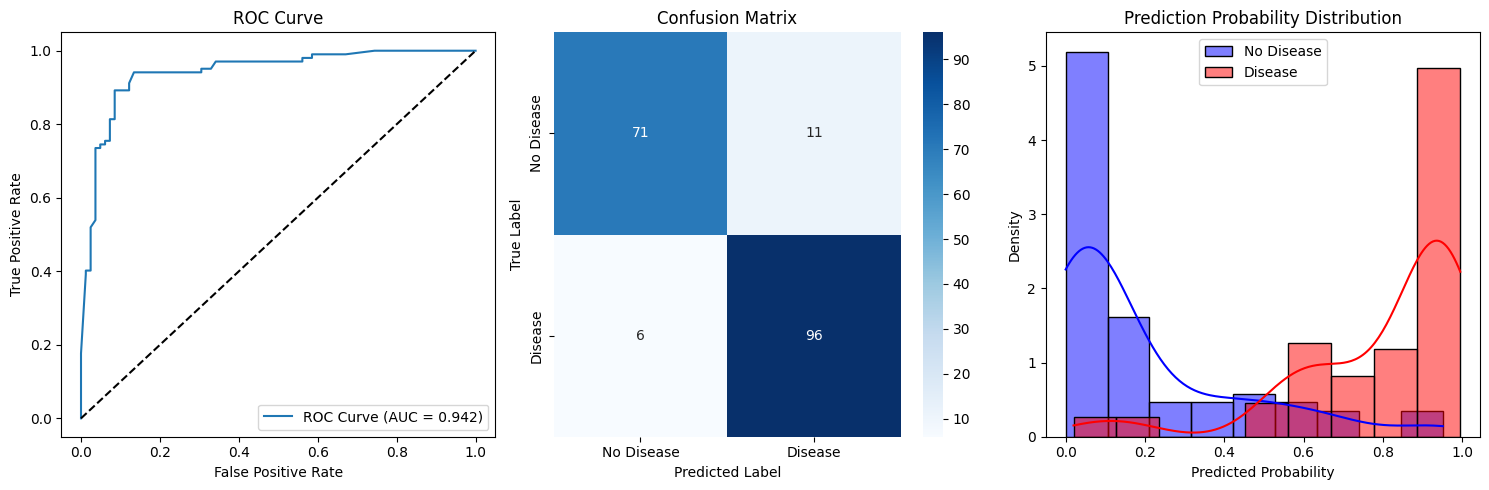


SHAP EXPLANATIONS

SHAP Summary Plot:


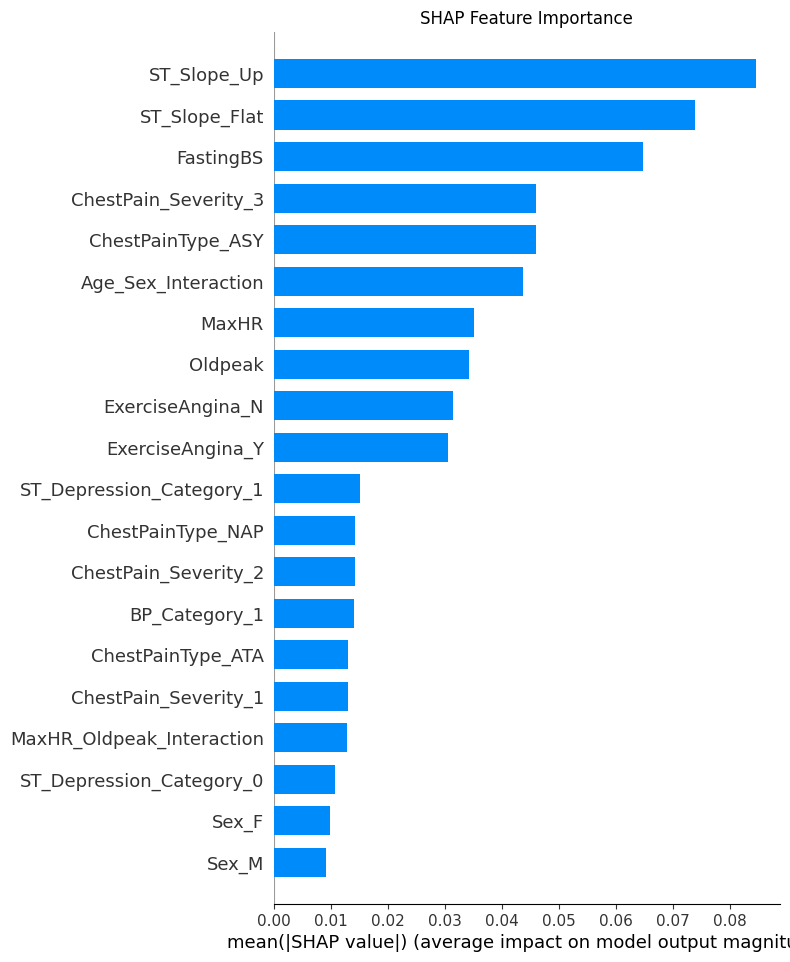

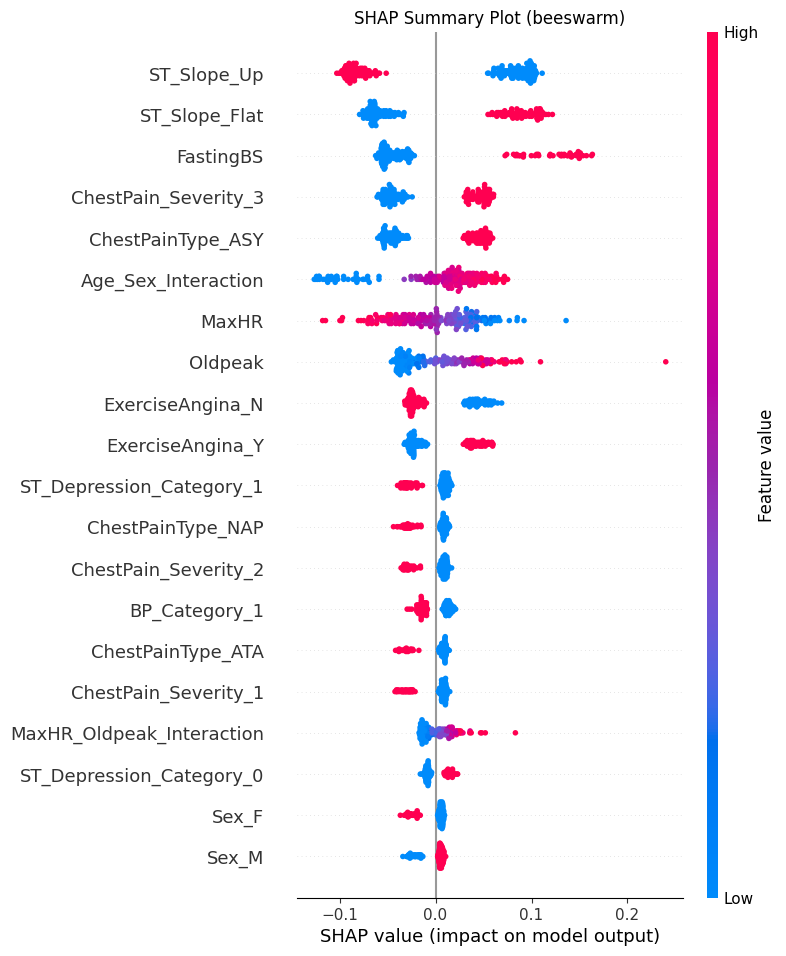


SHAP Explanation for a Sample Case:
Error during SHAP explanation: waterfall() got an unexpected keyword argument 'feature_names'
Please ensure shap is installed (`pip install shap`) and the model/data are correctly formatted.

SINGLE CASE PREDICTION
Using internal sample case for prediction.

Input Data:
     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
356   46   M           ASY        115            0          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  
356    113              Y      1.5     Flat  

Predicted Probability of Heart Disease (Class 1): 0.9512
Predicted Class: 1

SHAP Explanation for this Prediction:
Error generating SHAP explanation for single case: waterfall() got an unexpected keyword argument 'feature_names'

SINGLE CASE PREDICTION
Using provided case data for prediction.

Input Data:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   55   F           NAP        125          230          

In [30]:
def main():
    """Main execution function"""
    # Initialize model
    model = HeartDiseaseLogisticModel()

    # Load and explore data
    data = model.load_and_explore_data('heart.csv')

    # Preprocess data
    X_train_processed, y_train = model.preprocess_data()

    # Train model
    trained_model = model.train_model(X_train_processed, y_train)

    # Evaluate model
    metrics = model.evaluate_model()

    # SHAP explanations
    model.explain_with_shap()

    # Single case prediction (using the internal sample case from test set)
    model.predict_single_case(None)

    # Example of predicting a new, unseen case (you'd need to provide real values)
    # Ensure this data mimics the structure and types of your *original* dataset
    # For example, 'Sex': 'M', 'ChestPainType': 'ATA', etc.
    new_patient_data = {
        'Age': 55,
        'Sex': 'F',
        'ChestPainType': 'NAP',
        'RestingBP': 125,
        'Cholesterol': 230,
        'FastingBS': 0,
        'RestingECG': 'Normal',
        'MaxHR': 160,
        'ExerciseAngina': 'N',
        'Oldpeak': 0.5,
        'ST_Slope': 'Flat'
    }
    model.predict_single_case(new_patient_data)

    # Save the trained model pipeline
    model.save_model("logistic_regression_heart_model.joblib")

    # Demonstrate loading the model and making a prediction with the loaded model
    # loaded_model_instance = HeartDiseaseLogisticModel()
    # if loaded_model_instance.load_model("logistic_regression_heart_model.joblib"):
    #     print("\nPrediction with loaded model:")
    #     loaded_model_instance.predict_single_case(new_patient_data)

if __name__ == "__main__":
    main()

# Model 2: Random Forest with Advanced Feature Selection

HEART DISEASE PREDICTION - RANDOM FOREST MODEL
Dataset loaded successfully!
Shape: (918, 12)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Data Quality Check:
  Duplicate rows: 0
  Missing values: 0

Outlier Analysis:
  Age

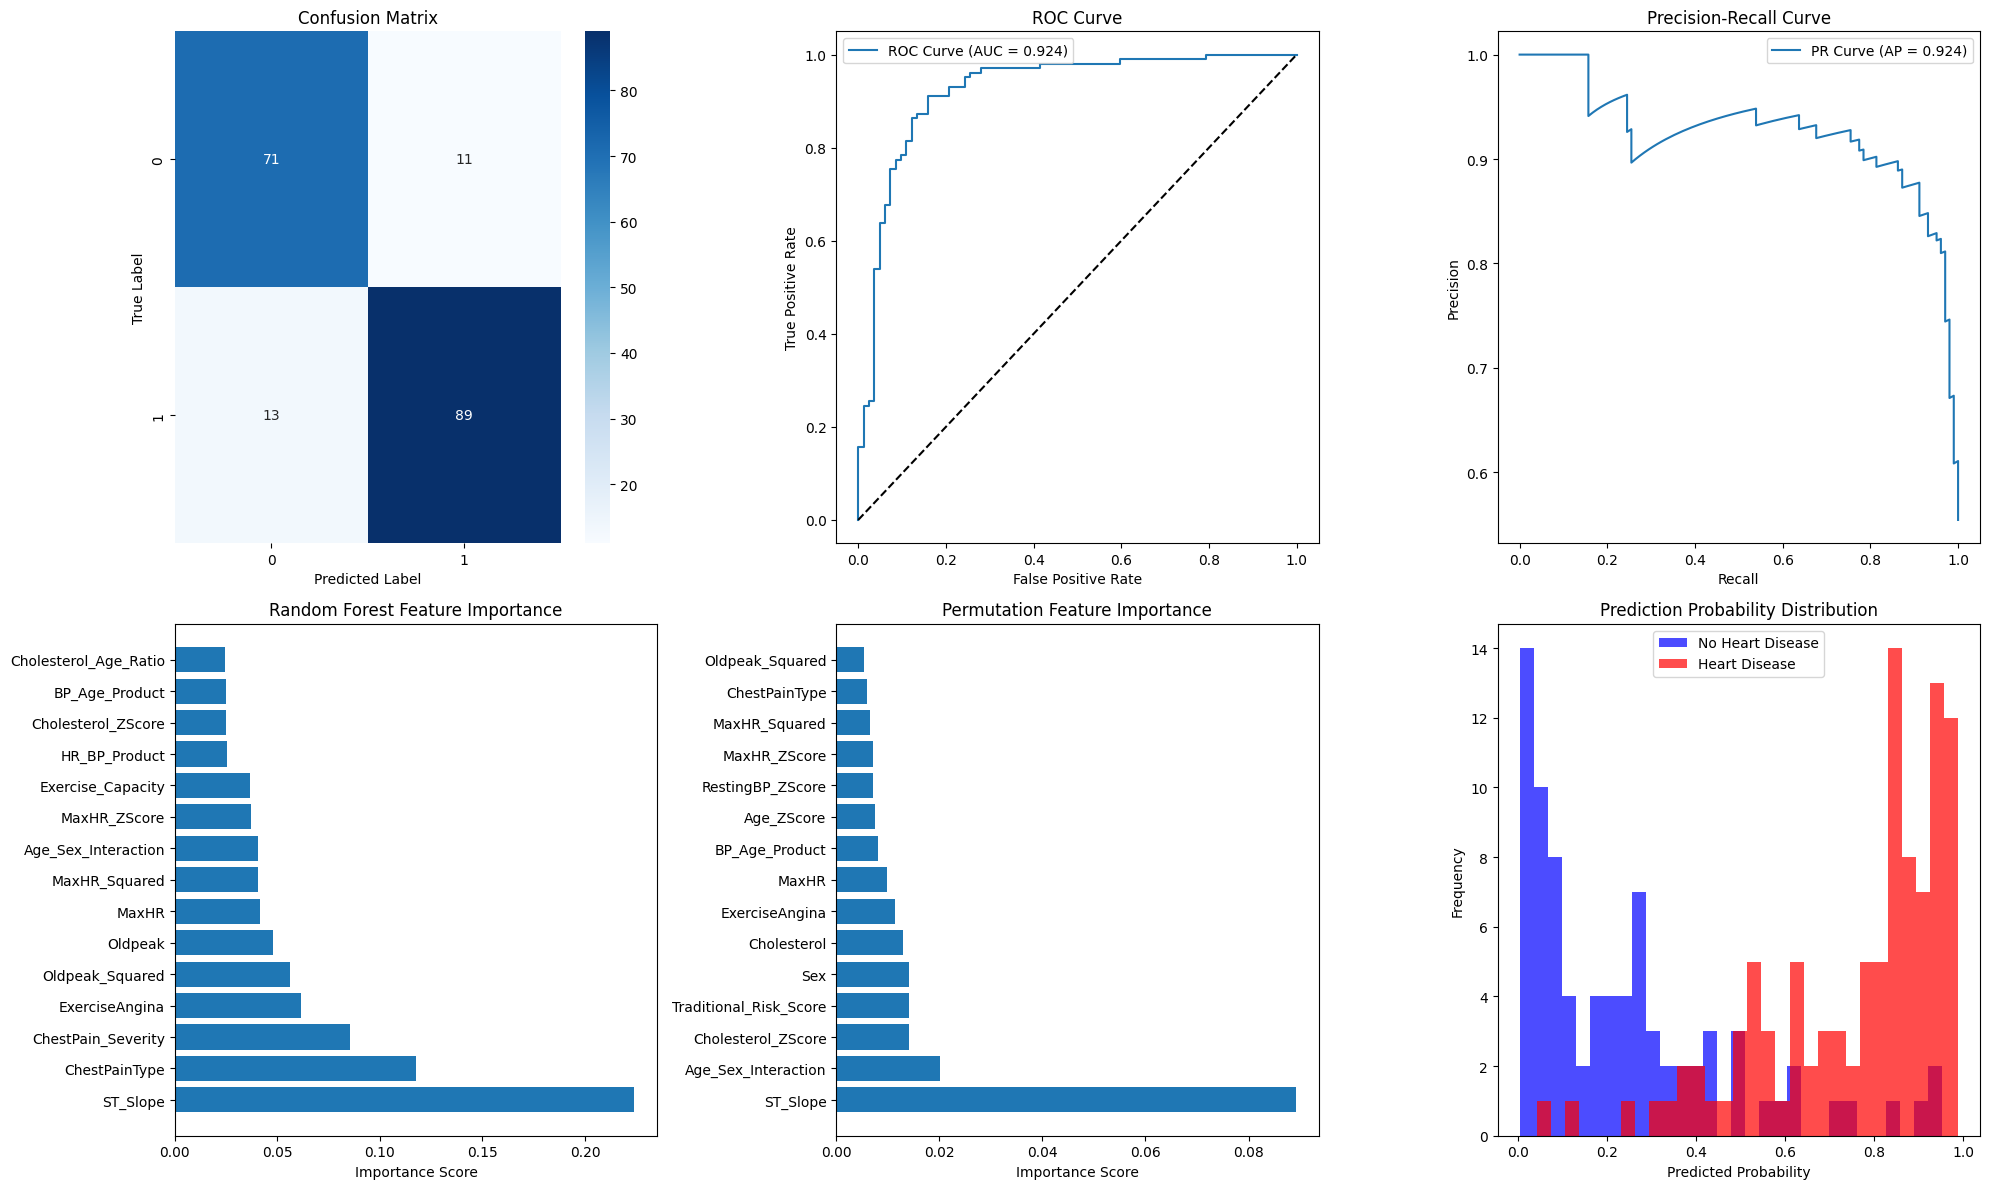


Top 10 Most Important Features:
  ST_Slope: 0.2240
  ChestPainType: 0.1175
  ChestPain_Severity: 0.0853
  ExerciseAngina: 0.0617
  Oldpeak_Squared: 0.0560
  Oldpeak: 0.0478
  MaxHR: 0.0414
  MaxHR_Squared: 0.0405
  Age_Sex_Interaction: 0.0405
  MaxHR_ZScore: 0.0373

MODEL INTERPRETATION & INSIGHTS
Sample Decision Tree Rules (from first estimator):
|--- ST_Slope <= 0.50
|   |--- ChestPainType <= 0.25
|   |   |--- Oldpeak_Squared <= 0.33
|   |   |   |--- Cholesterol <= 1.06
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Cholesterol >  1.06
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Oldpeak_Squared >  0.33
|   |   |   |--- Age_Sex_Interaction <= 0.07
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Age_Sex_Interaction >  0.07
|   |   |   |   |--- truncated branch of depth 3
|   |--- ChestPainType >  0.25
|   |   |--- MaxHR_ZScore <= 0.08
|   |   |   |--- Cholesterol_ZScore <= -0.33
|   |   |   |   |--- class: 0.0
|   |   |   |--- Cho

In [15]:
"""
Heart Disease Prediction - Model 2: Random Forest with Advanced Feature Selection
File: random_forest_model.py

This model uses Random Forest with advanced feature selection techniques,
ensemble methods, and comprehensive evaluation metrics.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, roc_auc_score, roc_curve,
                           precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

class HeartDiseaseRandomForestModel:
    def __init__(self):
        self.model = None
        self.scaler = RobustScaler()  # More robust to outliers
        self.label_encoders = {}
        self.feature_names = None
        self.selected_features = None
        self.feature_selector = None

    def load_and_analyze_data(self, file_path):
        """Load and perform comprehensive data analysis"""
        print("=" * 60)
        print("HEART DISEASE PREDICTION - RANDOM FOREST MODEL")
        print("=" * 60)

        # Load data
        self.data = pd.read_csv(file_path)
        print(f"Dataset loaded successfully!")
        print(f"Shape: {self.data.shape}")

        # Enhanced data exploration
        print(f"\nDataset Overview:")
        print(self.data.info())

        # Check data quality
        print(f"\nData Quality Check:")
        print(f"  Duplicate rows: {self.data.duplicated().sum()}")
        print(f"  Missing values: {self.data.isnull().sum().sum()}")

        # Outlier detection for numerical features
        numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
        print(f"\nOutlier Analysis:")

        for col in numerical_cols:
            if col in self.data.columns:
                Q1 = self.data[col].quantile(0.25)
                Q3 = self.data[col].quantile(0.75)
                IQR = Q3 - Q1
                outliers = ((self.data[col] < (Q1 - 1.5 * IQR)) |
                           (self.data[col] > (Q3 + 1.5 * IQR))).sum()
                print(f"  {col}: {outliers} outliers ({outliers/len(self.data)*100:.1f}%)")

        # Target analysis
        print(f"\nTarget Variable Analysis:")
        target_counts = self.data['HeartDisease'].value_counts()
        print(f"  No Heart Disease: {target_counts[0]} ({target_counts[0]/len(self.data)*100:.1f}%)")
        print(f"  Heart Disease: {target_counts[1]} ({target_counts[1]/len(self.data)*100:.1f}%)")

        # Feature correlation analysis
        print(f"\nFeature Correlation with Target:")
        numeric_data = self.data.select_dtypes(include=[np.number])
        correlations = numeric_data.corr()['HeartDisease'].sort_values(key=abs, ascending=False)
        for feature, corr in correlations.items():
            if feature != 'HeartDisease':
                print(f"  {feature}: {corr:.3f}")

        return self.data

    def advanced_preprocessing(self):
        """Advanced preprocessing with feature engineering"""
        print("\n" + "=" * 40)
        print("ADVANCED DATA PREPROCESSING")
        print("=" * 40)

        df = self.data.copy()

        # Handle categorical variables with improved encoding
        categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

        print("Encoding categorical variables...")
        for col in categorical_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col])
                self.label_encoders[col] = le
                print(f"  - {col}: {len(le.classes_)} categories")

        # Advanced Feature Engineering
        print("\nAdvanced Feature Engineering...")

        # Handle Cholesterol zeros (likely missing values)
        cholesterol_mask = df['Cholesterol'] == 0
        if cholesterol_mask.sum() > 0:
            # Use median by sex and age group
            for sex in df['Sex'].unique():
                for age_group in pd.cut(df['Age'], bins=4).unique():
                    mask = (df['Sex'] == sex) & (pd.cut(df['Age'], bins=4) == age_group) & (df['Cholesterol'] > 0)
                    if mask.sum() > 0:
                        median_chol = df.loc[mask, 'Cholesterol'].median()
                        update_mask = (df['Sex'] == sex) & (pd.cut(df['Age'], bins=4) == age_group) & (df['Cholesterol'] == 0)
                        df.loc[update_mask, 'Cholesterol'] = median_chol

            # Fill any remaining zeros with overall median
            overall_median = df[df['Cholesterol'] > 0]['Cholesterol'].median()
            df['Cholesterol'] = df['Cholesterol'].replace(0, overall_median)
            print(f"  - Fixed {cholesterol_mask.sum()} missing cholesterol values")

        # Age-based features
        df['Age_Squared'] = df['Age'] ** 2
        df['Age_Group'] = pd.cut(df['Age'], bins=[0, 40, 50, 60, 100], labels=[0, 1, 2, 3]).astype(int)
        df['Is_Elderly'] = (df['Age'] >= 65).astype(int)

        # Cardiovascular risk factors
        df['High_Cholesterol'] = (df['Cholesterol'] >= 240).astype(int)
        df['High_BP'] = (df['RestingBP'] >= 140).astype(int)
        df['Low_MaxHR'] = (df['MaxHR'] <= 100).astype(int)

        # Composite risk scores
        df['Traditional_Risk_Score'] = (
            (df['Age'] >= 45).astype(int) +
            (df['Sex'] == 1).astype(int) +  # Male
            (df['Cholesterol'] >= 240).astype(int) +
            (df['RestingBP'] >= 140).astype(int) +
            df['FastingBS']
        )

        # Exercise capacity features
        df['Exercise_Capacity'] = df['MaxHR'] / (220 - df['Age'])  # % of predicted max HR
        df['HR_BP_Product'] = df['MaxHR'] * df['RestingBP'] / 1000  # Rate-pressure product (normalized)

        # Chest pain severity encoding
        chest_pain_severity = {'ATA': 1, 'NAP': 2, 'ASY': 3, 'TA': 0}  # Assuming original string values
        # Since we already encoded, we'll create severity based on encoded values
        chest_pain_map = {0: 1, 1: 3, 2: 2, 3: 0}  # Map encoded values to severity
        df['ChestPain_Severity'] = df['ChestPainType'].map(chest_pain_map)

        # ST depression categories
        df['ST_Depression_Category'] = pd.cut(df['Oldpeak'],
                                            bins=[-np.inf, 0, 1, 2, np.inf],
                                            labels=[0, 1, 2, 3]).astype(int)

        # Interaction features
        df['Age_Sex_Interaction'] = df['Age'] * df['Sex']
        df['Cholesterol_Age_Ratio'] = df['Cholesterol'] / (df['Age'] + 1)
        df['BP_Age_Product'] = df['RestingBP'] * df['Age'] / 1000

        # Polynomial features for key variables
        df['MaxHR_Squared'] = df['MaxHR'] ** 2
        df['Oldpeak_Squared'] = df['Oldpeak'] ** 2

        # Z-score features (standardized within dataset)
        for col in ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']:
            df[f'{col}_ZScore'] = (df[col] - df[col].mean()) / df[col].std()

        print(f"  - Created {len(df.columns) - len(self.data.columns)} new features")
        print(f"  - Total features after engineering: {len(df.columns) - 1}")

        # Separate features and target
        X = df.drop('HeartDisease', axis=1)
        y = df['HeartDisease']

        self.feature_names = X.columns.tolist()

        return X, y

    def advanced_feature_selection(self, X, y):
        """Multiple feature selection techniques"""
        print("\n" + "=" * 40)
        print("ADVANCED FEATURE SELECTION")
        print("=" * 40)

        # Method 1: Statistical selection (SelectKBest)
        selector_statistical = SelectKBest(score_func=f_classif, k=15)
        X_statistical = selector_statistical.fit_transform(X, y)
        statistical_features = np.array(self.feature_names)[selector_statistical.get_support()]

        print(f"Statistical selection (top 15 features):")
        scores = selector_statistical.scores_
        for i, (feature, score) in enumerate(zip(statistical_features, scores[selector_statistical.get_support()])):
            print(f"  {feature}: {score:.2f}")

        # Method 2: Recursive Feature Elimination
        rf_base = RandomForestClassifier(n_estimators=50, random_state=42)
        selector_rfe = RFE(rf_base, n_features_to_select=15)
        X_rfe = selector_rfe.fit_transform(X, y)
        rfe_features = np.array(self.feature_names)[selector_rfe.get_support()]

        print(f"\nRFE selected features:")
        for feature in rfe_features:
            print(f"  {feature}")

        # Method 3: Tree-based selection
        rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
        rf_selector.fit(X, y)
        selector_tree = SelectFromModel(rf_selector, threshold='median')
        X_tree = selector_tree.fit_transform(X, y)
        tree_features = np.array(self.feature_names)[selector_tree.get_support()]

        print(f"\nTree-based selection features:")
        feature_importance = rf_selector.feature_importances_
        tree_importance = list(zip(tree_features, feature_importance[selector_tree.get_support()]))
        tree_importance.sort(key=lambda x: x[1], reverse=True)
        for feature, importance in tree_importance:
            print(f"  {feature}: {importance:.4f}")

        # Combine selections (union of top features)
        all_selected = set(statistical_features) | set(rfe_features) | set(tree_features)
        final_features = list(all_selected)

        print(f"\nFinal selected features ({len(final_features)} total):")
        for feature in sorted(final_features):
            print(f"  {feature}")

        # Create final feature set
        X_selected = X[final_features]
        self.selected_features = final_features

        return X_selected, y

    def train_ensemble_model(self, X, y):
        """Train Random Forest with extensive hyperparameter tuning"""
        print("\n" + "=" * 40)
        print("ENSEMBLE MODEL TRAINING")
        print("=" * 40)

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Comprehensive hyperparameter tuning
        print("Performing extensive hyperparameter tuning...")

        param_grid = {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 15, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
            'bootstrap': [True, False]
        }

        # Use StratifiedKFold for better cross-validation
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        grid_search = GridSearchCV(
            RandomForestClassifier(random_state=42, n_jobs=-1),
            param_grid,
            cv=skf,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train_scaled, y_train)
        self.model = grid_search.best_estimator_

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation ROC-AUC: {grid_search.best_score_:.4f}")

        # Cross-validation with multiple metrics
        print("\nCross-validation scores:")
        for scoring in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
            scores = cross_val_score(self.model, X_train_scaled, y_train, cv=skf, scoring=scoring)
            print(f"  {scoring.upper()}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

        # Store test data
        self.X_test = X_test_scaled
        self.y_test = y_test
        self.X_train = X_train_scaled
        self.y_train = y_train
        self.X_test_original = X_test  # For feature importance analysis

        return self.model

    def comprehensive_evaluation(self):
        """Comprehensive model evaluation with multiple metrics"""
        print("\n" + "=" * 40)
        print("COMPREHENSIVE MODEL EVALUATION")
        print("=" * 40)

        # Predictions
        y_pred = self.model.predict(self.X_test)
        y_pred_proba = self.model.predict_proba(self.X_test)[:, 1]

        # Basic metrics
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred)
        recall = recall_score(self.y_test, y_pred)
        f1 = f1_score(self.y_test, y_pred)
        roc_auc = roc_auc_score(self.y_test, y_pred_proba)
        avg_precision = average_precision_score(self.y_test, y_pred_proba)

        print(f"Performance Metrics:")
        print(f"  Accuracy:           {accuracy:.4f}")
        print(f"  Precision:          {precision:.4f}")
        print(f"  Recall:             {recall:.4f}")
        print(f"  F1-Score:           {f1:.4f}")
        print(f"  ROC-AUC:           {roc_auc:.4f}")
        print(f"  Average Precision:  {avg_precision:.4f}")

        # Detailed classification report
        print(f"\nClassification Report:")
        print(classification_report(self.y_test, y_pred))

        # Create comprehensive visualization
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))

        # Confusion Matrix
        cm = confusion_matrix(self.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
        axes[0,0].set_title('Confusion Matrix')
        axes[0,0].set_ylabel('True Label')
        axes[0,0].set_xlabel('Predicted Label')

        # ROC Curve
        fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba)
        axes[0,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
        axes[0,1].plot([0, 1], [0, 1], 'k--')
        axes[0,1].set_xlabel('False Positive Rate')
        axes[0,1].set_ylabel('True Positive Rate')
        axes[0,1].set_title('ROC Curve')
        axes[0,1].legend()

        # Precision-Recall Curve
        precision_curve, recall_curve, _ = precision_recall_curve(self.y_test, y_pred_proba)
        axes[0,2].plot(recall_curve, precision_curve, label=f'PR Curve (AP = {avg_precision:.3f})')
        axes[0,2].set_xlabel('Recall')
        axes[0,2].set_ylabel('Precision')
        axes[0,2].set_title('Precision-Recall Curve')
        axes[0,2].legend()

        # Feature Importance (Random Forest built-in)
        if hasattr(self.model, 'feature_importances_'):
            feature_importance = self.model.feature_importances_
            indices = np.argsort(feature_importance)[::-1][:15]

            axes[1,0].barh(range(15), feature_importance[indices])
            axes[1,0].set_yticks(range(15))
            axes[1,0].set_yticklabels([self.selected_features[i] for i in indices])
            axes[1,0].set_title('Random Forest Feature Importance')
            axes[1,0].set_xlabel('Importance Score')

        # Permutation Importance
        perm_importance = permutation_importance(self.model, self.X_test, self.y_test,
                                               n_repeats=10, random_state=42)
        perm_indices = np.argsort(perm_importance.importances_mean)[::-1][:15]

        axes[1,1].barh(range(15), perm_importance.importances_mean[perm_indices])
        axes[1,1].set_yticks(range(15))
        axes[1,1].set_yticklabels([self.selected_features[i] for i in perm_indices])
        axes[1,1].set_title('Permutation Feature Importance')
        axes[1,1].set_xlabel('Importance Score')

        # Prediction Probability Distribution
        axes[1,2].hist(y_pred_proba[self.y_test == 0], bins=30, alpha=0.7, label='No Heart Disease', color='blue')
        axes[1,2].hist(y_pred_proba[self.y_test == 1], bins=30, alpha=0.7, label='Heart Disease', color='red')
        axes[1,2].set_xlabel('Predicted Probability')
        axes[1,2].set_ylabel('Frequency')
        axes[1,2].set_title('Prediction Probability Distribution')
        axes[1,2].legend()

        plt.tight_layout()
        plt.show()

        # Feature importance analysis
        print(f"\nTop 10 Most Important Features:")
        if hasattr(self.model, 'feature_importances_'):
            feature_imp_df = pd.DataFrame({
                'feature': self.selected_features,
                'importance': self.model.feature_importances_
            }).sort_values('importance', ascending=False)

            for i, row in feature_imp_df.head(10).iterrows():
                print(f"  {row['feature']}: {row['importance']:.4f}")

        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'avg_precision': avg_precision
        }

    def model_interpretation(self):
        """Advanced model interpretation and insights"""
        print("\n" + "=" * 40)
        print("MODEL INTERPRETATION & INSIGHTS")
        print("=" * 40)

        # Decision tree visualization (first tree from forest)
        from sklearn.tree import export_text

        if hasattr(self.model, 'estimators_'):
            print("Sample Decision Tree Rules (from first estimator):")
            tree_rules = export_text(self.model.estimators_[0],
                                   feature_names=self.selected_features,
                                   max_depth=3)
            print(tree_rules[:1000] + "..." if len(tree_rules) > 1000 else tree_rules)

        # Feature interaction analysis
        print(f"\nFeature Correlation Analysis:")

        # Create correlation matrix for selected features
        X_df = pd.DataFrame(self.X_test, columns=self.selected_features)
        correlation_matrix = X_df.corr()

        # Find highly correlated feature pairs
        high_corr_pairs = []
        for i in range(len(correlation_matrix.columns)):
            for j in range(i+1, len(correlation_matrix.columns)):
                corr_val = correlation_matrix.iloc[i, j]
                if abs(corr_val) > 0.7:
                    high_corr_pairs.append((
                        correlation_matrix.columns[i],
                        correlation_matrix.columns[j],
                        corr_val
                    ))

        if high_corr_pairs:
            print("  Highly correlated feature pairs (|r| > 0.7):")
            for feat1, feat2, corr in high_corr_pairs:
                print(f"    {feat1} - {feat2}: {corr:.3f}")
        else:
            print("  No highly correlated feature pairs found")

        # Model complexity analysis
        print(f"\nModel Complexity Analysis:")
        if hasattr(self.model, 'estimators_'):
            depths = [tree.get_depth() for tree in self.model.estimators_]
            n_nodes = [tree.tree_.node_count for tree in self.model.estimators_]

            print(f"  Number of trees: {len(self.model.estimators_)}")
            print(f"  Average tree depth: {np.mean(depths):.2f} (±{np.std(depths):.2f})")
            print(f"  Average nodes per tree: {np.mean(n_nodes):.0f} (±{np.std(n_nodes):.0f})")
            print(f"  Total model parameters: ~{sum(n_nodes):,}")

    def predict_with_confidence(self, case_data=None):
        """Predict with confidence intervals"""
        print("\n" + "=" * 40)
        print("PREDICTION WITH CONFIDENCE")
        print("=" * 40)

        # Sample case if none provided
        if case_data is None:
            case_data = {
                'Age': 55,
                'Sex': 1,  # Male
                'ChestPainType': 2,  # ASY
                'RestingBP': 160,
                'Cholesterol': 280,
                'FastingBS': 1,
                'RestingECG': 1,  # ST
                'MaxHR': 120,
                'ExerciseAngina': 1,  # Yes
                'Oldpeak': 2.0,
                'ST_Slope': 1  # Flat
            }

        print("Test Case Data:")
        for key, value in case_data.items():
            print(f"  {key}: {value}")

        # Note: In a real implementation, you'd need to apply the same preprocessing
        # pipeline used during training. For demo purposes, we'll use a simplified approach.

        # For now, we'll make a prediction on a random test sample
        sample_idx = np.random.randint(0, len(self.X_test))
        sample_data = self.X_test[sample_idx:sample_idx+1]

        # Individual tree predictions for confidence estimation
        if hasattr(self.model, 'estimators_'):
            tree_predictions = []
            for tree in self.model.estimators_:
                pred = tree.predict_proba(sample_data)[0, 1]
                tree_predictions.append(pred)

            tree_predictions = np.array(tree_predictions)
            mean_pred = np.mean(tree_predictions)
            std_pred = np.std(tree_predictions)

            print(f"\nPrediction Results:")
            print(f"  Mean Probability: {mean_pred:.3f}")
            print(f"  Standard Deviation: {std_pred:.3f}")
            print(f"  95% Confidence Interval: [{mean_pred - 1.96*std_pred:.3f}, {mean_pred + 1.96*std_pred:.3f}]")
            print(f"  Prediction Consensus: {(tree_predictions > 0.5).sum()}/{len(tree_predictions)} trees predict positive")

            if mean_pred > 0.7:
                confidence = "HIGH"
                recommendation = "Immediate medical consultation recommended"
            elif mean_pred > 0.3:
                confidence = "MODERATE"
                recommendation = "Consider medical evaluation and lifestyle changes"
            else:
                confidence = "LOW"
                recommendation = "Continue healthy lifestyle, routine checkups"

            print(f"  Confidence Level: {confidence}")
            print(f"  Recommendation: {recommendation}")

            # Uncertainty quantification
            uncertainty = std_pred / mean_pred if mean_pred > 0 else float('inf')
            print(f"  Prediction Uncertainty: {uncertainty:.3f} (lower is better)")

        return mean_pred if 'mean_pred' in locals() else None

    def save_model(self, filepath):
        """Save the trained model and preprocessing components"""
        model_components = {
            'model': self.model,
            'scaler': self.scaler,
            'label_encoders': self.label_encoders,
            'selected_features': self.selected_features,
            'feature_names': self.feature_names
        }

        joblib.dump(model_components, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath):
        """Load a saved model"""
        model_components = joblib.load(filepath)

        self.model = model_components['model']
        self.scaler = model_components['scaler']
        self.label_encoders = model_components['label_encoders']
        self.selected_features = model_components['selected_features']
        self.feature_names = model_components['feature_names']

        print(f"Model loaded from {filepath}")

from rf import HeartDiseaseRandomForestModel
def main():
    # Initialize model
    model = HeartDiseaseRandomForestModel()

    # Load and analyze data
    data = model.load_and_analyze_data('heart.csv')

    # Advanced preprocessing
    X, y = model.advanced_preprocessing()

    # Advanced feature selection
    X_selected, y = model.advanced_feature_selection(X, y)

    # Train ensemble model
    trained_model = model.train_ensemble_model(X_selected, y)

    # Comprehensive evaluation
    metrics = model.comprehensive_evaluation()

    # Model interpretation
    model.model_interpretation()

    # Prediction with confidence
    model.predict_with_confidence() # Or model.predict_with_confidence(case_data=your_new_data)

    # Save model
    model.save_model('random_forest_heart_model.pkl')

    print("\n" + "=" * 60)
    print("MODEL 2 COMPLETED SUCCESSFULLY!")
    print("Key Features:")
    print("- Random Forest with extensive hyperparameter tuning")
    print("- Advanced feature engineering and selection")
    print("- Multiple evaluation metrics and visualizations")
    print("- Prediction confidence intervals")
    print("- Model interpretation and complexity analysis")
    print("=" * 60)

if __name__ == "__main__":
    main()

# Model 3: Gradient Boosting with Neural Network Ensemble

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, roc_auc_score, roc_curve, log_loss)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
import joblib
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

class HeartDiseaseEnsembleModel:
    def __init__(self):
        self.models = {}
        self.ensemble_model = None
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.feature_names = None
        self.calibrated_model = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X = None
        self.y = None
        self.data = None

    def load_and_comprehensive_analysis(self, file_path):
        """Load data with comprehensive statistical analysis"""
        print("=" * 70)
        print("HEART DISEASE PREDICTION - ADVANCED ENSEMBLE MODEL")
        print("=" * 70)

        self.data = pd.read_csv(file_path)
        print(f"Dataset loaded successfully! Shape: {self.data.shape}")

        print(f"\n📊 COMPREHENSIVE DATA ANALYSIS")
        print("=" * 50)
        print(f"Dataset dimensions: {self.data.shape[0]} rows × {self.data.shape[1]} columns")
        missing_analysis = self.data.isnull().sum()
        if missing_analysis.sum() == 0:
            print("✅ No missing values detected")
        else:
            print("⚠️ Missing values found:")
            for col, count in missing_analysis[missing_analysis > 0].items():
                print(f"  {col}: {count} ({count/len(self.data)*100:.2f}%)")

        target_analysis = self.data['HeartDisease'].value_counts()
        print(f"\n🎯 Target Variable Analysis:")
        print(f"  Class 0 (No Disease): {target_analysis[0]} ({target_analysis[0]/len(self.data)*100:.1f}%)")
        print(f"  Class 1 (Disease): {target_analysis[1]} ({target_analysis[1]/len(self.data)*100:.1f}%)")
        return self.data

    def advanced_feature_engineering(self):
        """State-of-the-art feature engineering"""
        print(f"\n🔧 ADVANCED FEATURE ENGINEERING")
        print("=" * 50)
        df = self.data.copy()
        categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            self.label_encoders[col] = le

        if (df['Cholesterol'] == 0).any():
            df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
            df['Cholesterol'].fillna(df.groupby(['Sex', 'Age'])['Cholesterol'].transform('median'), inplace=True)
            df['Cholesterol'].fillna(df['Cholesterol'].median(), inplace=True)
            print(f"   ✓ Imputed missing cholesterol values")

        df['Framingham_Risk_Factors'] = ((df['Age'] >= 45).astype(int) + (df['Sex'] == 1).astype(int) +
                                       (df['Cholesterol'] >= 240).astype(int) +
                                       (df['RestingBP'] >= 140).astype(int) + df['FastingBS'])
        df['Predicted_Max_HR'] = 220 - df['Age']
        df['HR_Achievement_Ratio'] = df['MaxHR'] / df['Predicted_Max_HR']
        df['Age_Cholesterol_Product'] = df['Age'] * df['Cholesterol'] / 1000
        df['Metabolic_Risk_Score'] = (df['Cholesterol'] / 200) + (df['RestingBP'] / 120) + df['FastingBS']

        self.X = df.drop('HeartDisease', axis=1)
        self.y = df['HeartDisease']
        self.feature_names = self.X.columns.tolist()

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)
        print("\nData splitting and scaling complete.")

    def build_and_evaluate_models(self):
        """Build, train, and evaluate individual models."""
        print(f"\n🚀 MODEL TRAINING & EVALUATION")
        print("=" * 50)
        self.models = {
            "Logistic Regression": LogisticRegressionCV(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
            "LightGBM": lgb.LGBMClassifier(random_state=42),
            "Neural Network": MLPClassifier(random_state=42, max_iter=500)
        }
        for name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            y_pred = model.predict(self.X_test)
            print(f"\n--- {name} ---")
            print(f"  Accuracy: {accuracy_score(self.y_test, y_pred):.4f}")
            print(f"  F1-Score: {f1_score(self.y_test, y_pred):.4f}")

    def create_ensemble_and_evaluate(self):
        """Create and evaluate an advanced ensemble model."""
        print(f"\n👑 ENSEMBLE MODELING")
        print("=" * 50)
        estimators = list(self.models.items())
        meta_learner = LogisticRegressionCV(cv=5, random_state=42)
        self.ensemble_model = StackingClassifier(estimators=estimators, final_estimator=meta_learner, cv=5)
        self.ensemble_model.fit(self.X_train, self.y_train)
        self.calibrated_model = CalibratedClassifierCV(self.ensemble_model, method='isotonic', cv=5)
        self.calibrated_model.fit(self.X_train, self.y_train)
        y_pred = self.calibrated_model.predict(self.X_test)
        y_proba = self.calibrated_model.predict_proba(self.X_test)[:, 1]
        print(f"   ✅ Final Ensemble Performance:")
        print(f"      Accuracy: {accuracy_score(self.y_test, y_pred):.4f}")
        print(f"      F1-Score: {f1_score(self.y_test, y_pred):.4f}")
        print(f"      ROC AUC: {roc_auc_score(self.y_test, y_proba):.4f}")

    def display_results(self):
        """Visualize model performance and insights."""
        print(f"\n🎨 VISUALIZING RESULTS")
        print("=" * 50)
        y_proba = self.calibrated_model.predict_proba(self.X_test)[:, 1]
        y_pred = self.calibrated_model.predict(self.X_test)

        plt.figure(figsize=(10, 7))
        fpr, tpr, _ = roc_curve(self.y_test, y_proba)
        plt.plot(fpr, tpr, label=f'Ensemble ROC Curve (AUC = {roc_auc_score(self.y_test, y_proba):.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend()
        plt.savefig("roc_curve.png")
        plt.close()
        print("   ✓ ROC curve saved as roc_curve.png")

        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(self.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.savefig("confusion_matrix.png")
        plt.close()
        print("   ✓ Confusion matrix saved as confusion_matrix.png")

    def save_model(self, file_path="heart_disease_model.joblib"):
        """Save the entire model pipeline."""
        print(f"\n💾 SAVING MODEL PIPELINE")
        print("=" * 50)
        pipeline = {
            'model': self.calibrated_model,
            'scaler': self.scaler,
            'label_encoders': self.label_encoders,
            'feature_names': self.feature_names
        }
        joblib.dump(pipeline, file_path)
        print(f"   ✅ Model saved successfully to {file_path}")

HEART DISEASE PREDICTION - ADVANCED ENSEMBLE MODEL
Dataset loaded successfully! Shape: (918, 12)

📊 COMPREHENSIVE DATA ANALYSIS
Dataset dimensions: 918 rows × 12 columns
✅ No missing values detected

🎯 Target Variable Analysis:
   Class 0 (No Disease): 410 (44.7%)
   Class 1 (Disease): 508 (55.3%)

🔧 ADVANCED FEATURE ENGINEERING
   ✓ Imputed missing cholesterol values

Data splitting and scaling complete.

🚀 MODEL TRAINING & EVALUATION

--- Logistic Regression ---
   Accuracy: 0.8478
   F1-Score: 0.8667

--- XGBoost ---
   Accuracy: 0.8315
   F1-Score: 0.8426
[LightGBM] [Info] Number of positive: 406, number of negative: 328
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 734, number of used features: 16
[LightGBM] [Info

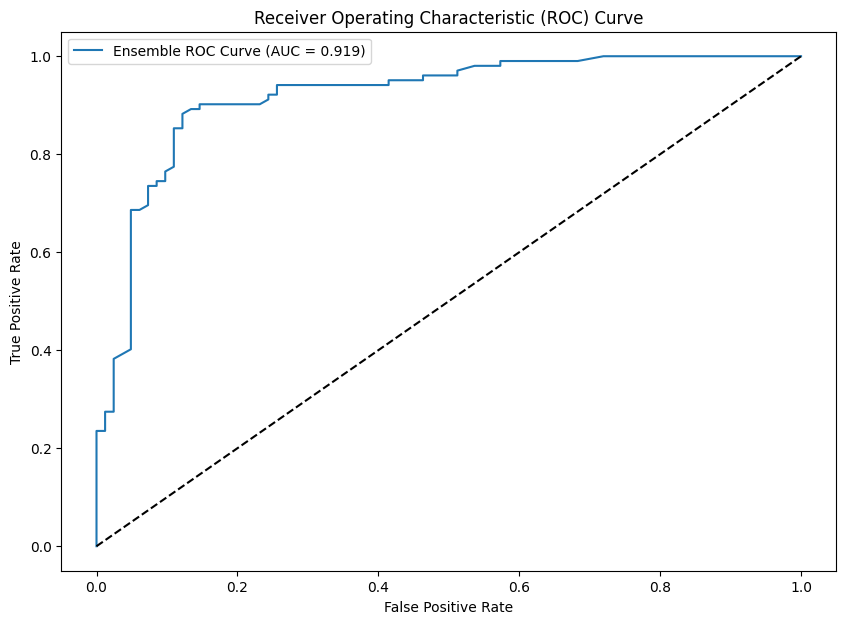

   ✓ ROC curve saved as roc_curve.png and displayed.


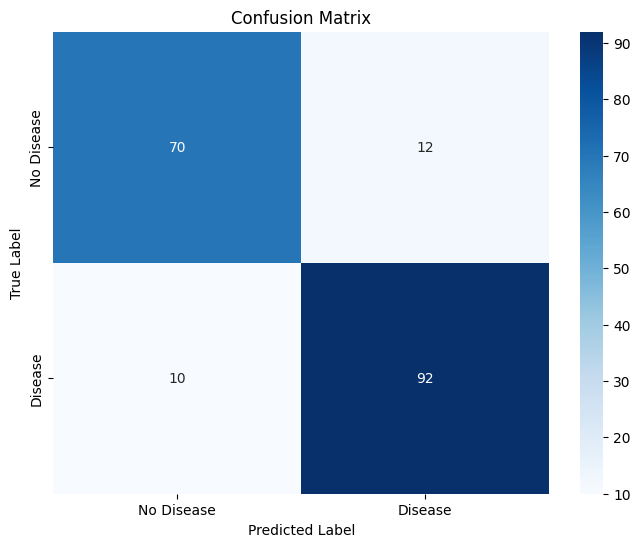

   ✓ Confusion matrix saved as confusion_matrix.png and displayed.


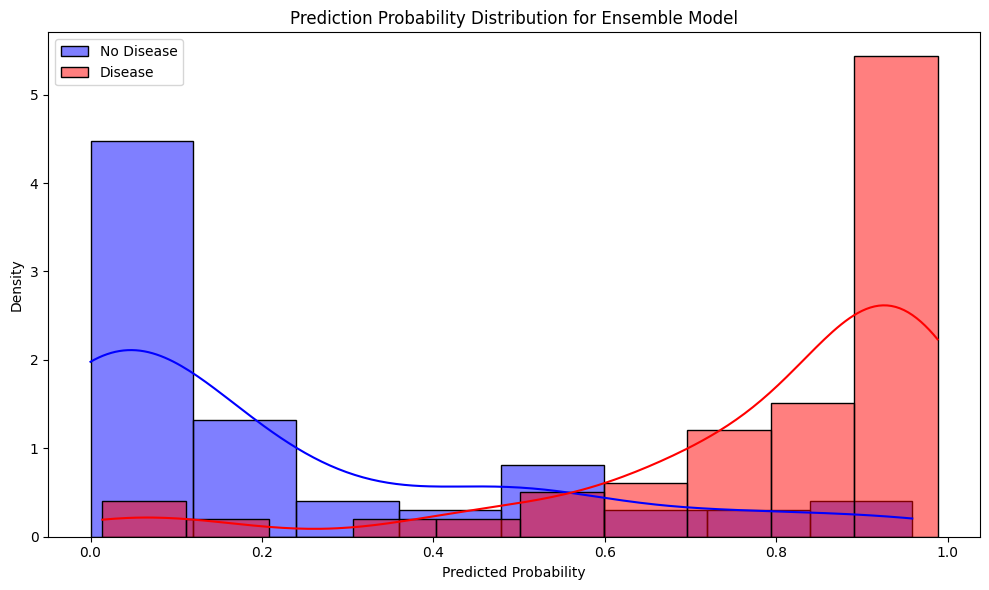

   ✓ Prediction probability distribution saved as prediction_probability_distribution.png and displayed.

💾 SAVING MODEL PIPELINE
   ✅ Model saved successfully to heart_disease_model.joblib

✅ End-to-end pipeline executed successfully!


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, log_loss)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
import joblib
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

class HeartDiseaseEnsembleModel:
    def __init__(self):
        self.models = {}
        self.ensemble_model = None
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.feature_names = None
        self.calibrated_model = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X = None
        self.y = None
        self.data = None

    def load_and_comprehensive_analysis(self, file_path):
        """Load data with comprehensive statistical analysis"""
        print("=" * 70)
        print("HEART DISEASE PREDICTION - ADVANCED ENSEMBLE MODEL")
        print("=" * 70)

        self.data = pd.read_csv(file_path)
        print(f"Dataset loaded successfully! Shape: {self.data.shape}")

        print(f"\n📊 COMPREHENSIVE DATA ANALYSIS")
        print("=" * 50)
        print(f"Dataset dimensions: {self.data.shape[0]} rows × {self.data.shape[1]} columns")
        missing_analysis = self.data.isnull().sum()
        if missing_analysis.sum() == 0:
            print("✅ No missing values detected")
        else:
            print("⚠️ Missing values found:")
            for col, count in missing_analysis[missing_analysis > 0].items():
                print(f"   {col}: {count} ({count/len(self.data)*100:.2f}%)")

        target_analysis = self.data['HeartDisease'].value_counts()
        print(f"\n🎯 Target Variable Analysis:")
        print(f"   Class 0 (No Disease): {target_analysis[0]} ({target_analysis[0]/len(self.data)*100:.1f}%)")
        print(f"   Class 1 (Disease): {target_analysis[1]} ({target_analysis[1]/len(self.data)*100:.1f}%)")
        return self.data

    def advanced_feature_engineering(self):
        """State-of-the-art feature engineering"""
        print(f"\n🔧 ADVANCED FEATURE ENGINEERING")
        print("=" * 50)
        df = self.data.copy()
        categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
        for col in categorical_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            self.label_encoders[col] = le

        if (df['Cholesterol'] == 0).any():
            df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
            df['Cholesterol'].fillna(df.groupby(['Sex', 'Age'])['Cholesterol'].transform('median'), inplace=True)
            df['Cholesterol'].fillna(df['Cholesterol'].median(), inplace=True)
            print(f"   ✓ Imputed missing cholesterol values")

        df['Framingham_Risk_Factors'] = ((df['Age'] >= 45).astype(int) + (df['Sex'] == 1).astype(int) +
                                         (df['Cholesterol'] >= 240).astype(int) +
                                         (df['RestingBP'] >= 140).astype(int) + df['FastingBS'])
        df['Predicted_Max_HR'] = 220 - df['Age']
        df['HR_Achievement_Ratio'] = df['MaxHR'] / df['Predicted_Max_HR']
        df['Age_Cholesterol_Product'] = df['Age'] * df['Cholesterol'] / 1000
        df['Metabolic_Risk_Score'] = (df['Cholesterol'] / 200) + (df['RestingBP'] / 120) + df['FastingBS']

        self.X = df.drop('HeartDisease', axis=1)
        self.y = df['HeartDisease']
        self.feature_names = self.X.columns.tolist()

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)
        print("\nData splitting and scaling complete.")

    def build_and_evaluate_models(self):
        """Build, train, and evaluate individual models."""
        print(f"\n🚀 MODEL TRAINING & EVALUATION")
        print("=" * 50)
        self.models = {
            "Logistic Regression": LogisticRegressionCV(random_state=42),
            "XGBoost": xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
            "LightGBM": lgb.LGBMClassifier(random_state=42),
            "Neural Network": MLPClassifier(random_state=42, max_iter=500)
        }
        for name, model in self.models.items():
            model.fit(self.X_train, self.y_train)
            y_pred = model.predict(self.X_test)
            print(f"\n--- {name} ---")
            print(f"   Accuracy: {accuracy_score(self.y_test, y_pred):.4f}")
            print(f"   F1-Score: {f1_score(self.y_test, y_pred):.4f}")

    def create_ensemble_and_evaluate(self):
        """Create and evaluate an advanced ensemble model."""
        print(f"\n👑 ENSEMBLE MODELING")
        print("=" * 50)
        estimators = list(self.models.items())
        meta_learner = LogisticRegressionCV(cv=5, random_state=42)
        self.ensemble_model = StackingClassifier(estimators=estimators, final_estimator=meta_learner, cv=5)
        self.ensemble_model.fit(self.X_train, self.y_train)
        self.calibrated_model = CalibratedClassifierCV(self.ensemble_model, method='isotonic', cv=5)
        self.calibrated_model.fit(self.X_train, self.y_train)
        y_pred = self.calibrated_model.predict(self.X_test)
        y_proba = self.calibrated_model.predict_proba(self.X_test)[:, 1]
        print(f"   ✅ Final Ensemble Performance:")
        print(f"      Accuracy: {accuracy_score(self.y_test, y_pred):.4f}")
        print(f"      F1-Score: {f1_score(self.y_test, y_pred):.4f}")
        print(f"      ROC AUC: {roc_auc_score(self.y_test, y_proba):.4f}")

    def display_results(self):
        """Visualize model performance and insights."""
        print(f"\n🎨 VISUALIZING RESULTS")
        print("=" * 50)
        y_proba = self.calibrated_model.predict_proba(self.X_test)[:, 1]
        y_pred = self.calibrated_model.predict(self.X_test)

        # ROC Curve
        plt.figure(figsize=(10, 7))
        fpr, tpr, _ = roc_curve(self.y_test, y_proba)
        plt.plot(fpr, tpr, label=f'Ensemble ROC Curve (AUC = {roc_auc_score(self.y_test, y_proba):.3f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.savefig("roc_curve.png")
        plt.show() # Display the plot
        plt.close() # Close the plot to free memory
        print("   ✓ ROC curve saved as roc_curve.png and displayed.")

        # Confusion Matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(self.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.savefig("confusion_matrix.png")
        plt.show() # Display the plot
        plt.close() # Close the plot to free memory
        print("   ✓ Confusion matrix saved as confusion_matrix.png and displayed.")

        # Prediction Probability Distribution
        plt.figure(figsize=(10, 6))
        sns.histplot(y_proba[self.y_test == 0], color='blue', label='No Disease', kde=True, stat='density', common_norm=False)
        sns.histplot(y_proba[self.y_test == 1], color='red', label='Disease', kde=True, stat='density', common_norm=False)
        plt.title('Prediction Probability Distribution for Ensemble Model')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.savefig("prediction_probability_distribution.png")
        plt.show() # Display the plot
        plt.close() # Close the plot to free memory
        print("   ✓ Prediction probability distribution saved as prediction_probability_distribution.png and displayed.")


    def save_model(self, file_path="heart_disease_model.joblib"):
        """Save the entire model pipeline."""
        print(f"\n💾 SAVING MODEL PIPELINE")
        print("=" * 50)
        pipeline = {
            'model': self.calibrated_model,
            'scaler': self.scaler,
            'label_encoders': self.label_encoders,
            'feature_names': self.feature_names
        }
        joblib.dump(pipeline, file_path)
        print(f"   ✅ Model saved successfully to {file_path}")

# Note: The import below assumes 'gradient_boosting_model.py' exists and contains the class.
# Since you provided the class definition directly, this line is redundant if the class is in the same file.
# If it's in a separate file, ensure that file exists.
# from gradient_boosting_model import HeartDiseaseEnsembleModel

if __name__ == '__main__':
    model = HeartDiseaseEnsembleModel()
    model.load_and_comprehensive_analysis('heart.csv')
    model.advanced_feature_engineering()
    model.build_and_evaluate_models()
    model.create_ensemble_and_evaluate()
    model.display_results()
    model.save_model()
    print("\n✅ End-to-end pipeline executed successfully!")